In [1]:
# ML4Sci GSoC 2026: Task VI.B - Transfer Learning & Domain Adaptation
# Author: Kartik Chavan
# Task: Fine-tuning the SRCNN model on 300 real HST/HSC telescope image pairs.
# Strategy: Transfer learning from Task VI.A + Paired geometric data augmentation to combat the ultra-small dataset size.

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt
from pathlib import Path

# hardware mapping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"hardware locked: {device}")

# Dynamic Path Resolution using modern pathlib (OS-agnostic)
search_base = Path("../data/raw/Task_VI_B_RealTelescope")
try:
    LR_DIR_VIB = next(search_base.rglob("LR"))
    HR_DIR_VIB = next(search_base.rglob("HR"))
    print(f"target acquired. LR path locked: {LR_DIR_VIB}")
    print(f"target acquired. HR path locked: {HR_DIR_VIB}")
except StopIteration:
    print("CRITICAL: LR or HR directories not found. Check extraction path.")

class RealTelescopeDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, augment=False):
        # pathlib globbing and sorting
        self.lr_paths = sorted(list(Path(lr_dir).glob("*.npy")))
        self.hr_paths = sorted(list(Path(hr_dir).glob("*.npy")))
        self.augment = augment
        
    def __len__(self):
        return len(self.lr_paths)
    
    def __getitem__(self, idx):
        # loading raw numpy arrays
        lr_img = np.load(self.lr_paths[idx]).astype(np.float32)
        hr_img = np.load(self.hr_paths[idx]).astype(np.float32)
        
        # sanitizing hidden dimensions from raw telescope data before adding channel
        lr_tensor = torch.from_numpy(lr_img).squeeze().unsqueeze(0)
        hr_tensor = torch.from_numpy(hr_img).squeeze().unsqueeze(0)
        
        # enforcing strict [0, 1] normalization for telescope sensors
        lr_tensor = torch.clamp(lr_tensor, 0.0, 1.0)
        hr_tensor = torch.clamp(hr_tensor, 0.0, 1.0)
        
        # applying identical paired augmentations to artificially expand the 300 dataset
        if self.augment:
            if random.random() > 0.5:
                lr_tensor = TF.hflip(lr_tensor)
                hr_tensor = TF.hflip(hr_tensor)
            if random.random() > 0.5:
                lr_tensor = TF.vflip(lr_tensor)
                hr_tensor = TF.vflip(hr_tensor)
            if random.random() > 0.5:
                # 90 deg rotations keep pixel grids intact
                angles = [90, 180, 270]
                angle = random.choice(angles)
                lr_tensor = TF.rotate(lr_tensor, angle)
                hr_tensor = TF.rotate(hr_tensor, angle)
                
        return lr_tensor, hr_tensor

print("dataset architecture loaded.")

hardware locked: cuda
target acquired. LR path locked: ..\data\raw\Task_VI_B_RealTelescope\Dataset\LR
target acquired. HR path locked: ..\data\raw\Task_VI_B_RealTelescope\Dataset\HR
dataset architecture loaded.


In [2]:
import os

# mapping the directory contents to find the exact extraction path
base_dir = "../data/raw/Task_VI_B_RealTelescope/"
print(f"Contents of base_dir: {os.listdir(base_dir)}")

Contents of base_dir: ['Dataset']


In [3]:
# building the loaders with an 80/20 split
full_dataset = RealTelescopeDataset(LR_DIR_VIB, HR_DIR_VIB, augment=True)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# splitting without breaking random seeds
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# batch size is smaller here (16) so to prevent overfitting on small data, doing this
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"train pairs: {len(train_dataset)} | val pairs: {len(val_dataset)}")

# grabbing a batch to sanity check the shapes
lr_batch, hr_batch = next(iter(train_loader))
print(f"lr batch shape: {lr_batch.shape}")
print(f"hr batch shape: {hr_batch.shape}")

train pairs: 240 | val pairs: 60
lr batch shape: torch.Size([16, 1, 64, 64])
hr batch shape: torch.Size([16, 1, 128, 128])


In [4]:
import sys
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from sr_models import SRCNN

# pulling the base architecture
model = SRCNN().to(device)

# injecting pre-trained knowledge from Task VI.A
weights_path = "../models/task_via_srcnn.pth" 

if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"successfully injected pre-trained weights from {weights_path}")
else:
    print("WARNING: pre-trained weights not found. training from scratch.")

# dropping the learning rate heavily (1e-4) for fine-tuning
# we just want to nudge the weights, not destroy them
LEARNING_RATE = 1e-4 
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# using standard MSE here since telescope data is highly susceptible to structural metric collapse
criterion = nn.MSELoss()
print("model and optimizer locked for fine-tuning.")

successfully injected pre-trained weights from ../models/task_via_srcnn.pth
model and optimizer locked for fine-tuning.


In [5]:
# fine-tuning parameters
# keeping epochs low (15) to prevent catastrophic forgetting of the VI.A physics
EPOCHS = 15
best_val_loss = float('inf')
save_path_vib = "../models/task_vib_transfer_srcnn.pth"

# creating storage if missing
os.makedirs("../models", exist_ok=True)

print("initiating domain adaptation fine-tuning on HST/HSC data...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for lr_imgs, hr_imgs in train_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        
        optimizer.zero_grad()
        outputs = model(lr_imgs)
        
        # relying purely on MSE here to stabilize the volatile real-world sensor noise
        loss = criterion(outputs, hr_imgs)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # locking the model for validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            loss = criterion(outputs, hr_imgs)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # checkpointing the optimal weights dynamically
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path_vib)
        save_flag = "checkpoint secured! Woohooo!"
    else:
        save_flag = ""
        
    print(f"epoch {epoch+1:02d}/{EPOCHS} | train_mse: {avg_train_loss:.6f} | val_mse: {avg_val_loss:.6f} {save_flag}")

print("fine-tuning sequence terminated. transfer learning complete.")

initiating domain adaptation fine-tuning on HST/HSC data...
epoch 01/15 | train_mse: 0.005324 | val_mse: 0.001873 checkpoint secured! Woohooo!
epoch 02/15 | train_mse: 0.002078 | val_mse: 0.000947 checkpoint secured! Woohooo!
epoch 03/15 | train_mse: 0.001859 | val_mse: 0.000901 checkpoint secured! Woohooo!
epoch 04/15 | train_mse: 0.001793 | val_mse: 0.000902 
epoch 05/15 | train_mse: 0.001748 | val_mse: 0.000873 checkpoint secured! Woohooo!
epoch 06/15 | train_mse: 0.001727 | val_mse: 0.000833 checkpoint secured! Woohooo!
epoch 07/15 | train_mse: 0.001713 | val_mse: 0.000814 checkpoint secured! Woohooo!
epoch 08/15 | train_mse: 0.001690 | val_mse: 0.000770 checkpoint secured! Woohooo!
epoch 09/15 | train_mse: 0.001667 | val_mse: 0.000755 checkpoint secured! Woohooo!
epoch 10/15 | train_mse: 0.001636 | val_mse: 0.000701 checkpoint secured! Woohooo!
epoch 11/15 | train_mse: 0.001631 | val_mse: 0.000692 checkpoint secured! Woohooo!
epoch 12/15 | train_mse: 0.001608 | val_mse: 0.000670 c

In [6]:
import math
from skimage.metrics import structural_similarity as ssim

# loading the absolute best weights from the fine-tuning run
model.load_state_dict(torch.load(save_path_vib))
model.eval()

total_psnr = 0.0
all_ssim = []
total_mse = 0.0

print("running final evaluation metrics on real telescope data...")

with torch.no_grad():
    for lr_imgs, hr_imgs in val_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        outputs = model(lr_imgs)
        
        # calculating batch MSE
        batch_mse = criterion(outputs, hr_imgs).item()
        total_mse += batch_mse
        
        # calculating batch PSNR
        if batch_mse > 0:
            total_psnr += 10 * math.log10(1.0 / batch_mse)
        else:
            total_psnr += 100
            
        # pushing to cpu for structural metric analysis
        preds = outputs.cpu().numpy().squeeze()
        targets = hr_imgs.cpu().numpy().squeeze()
        
        # executing safe clipping to avoid tensor range crashes
        for j in range(preds.shape[0]):
            p = np.clip(preds[j], 0, 1)
            t = np.clip(targets[j], 0, 1)
            score = ssim(t, p, data_range=1.0, win_size=3, gaussian_weights=True, sigma=1.5)
            all_ssim.append(score)

# averaging out the metrics
final_mse = total_mse / len(val_loader)
final_psnr = total_psnr / len(val_loader)
final_ssim = np.mean(all_ssim)

print(f"--- Final Task VI.B Metrics ---")
print(f"MSE:  {final_mse:.6f}")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")

running final evaluation metrics on real telescope data...
--- Final Task VI.B Metrics ---
MSE:  0.000636
PSNR: 31.99 dB
SSIM: 0.8355


rendering visual metrics...


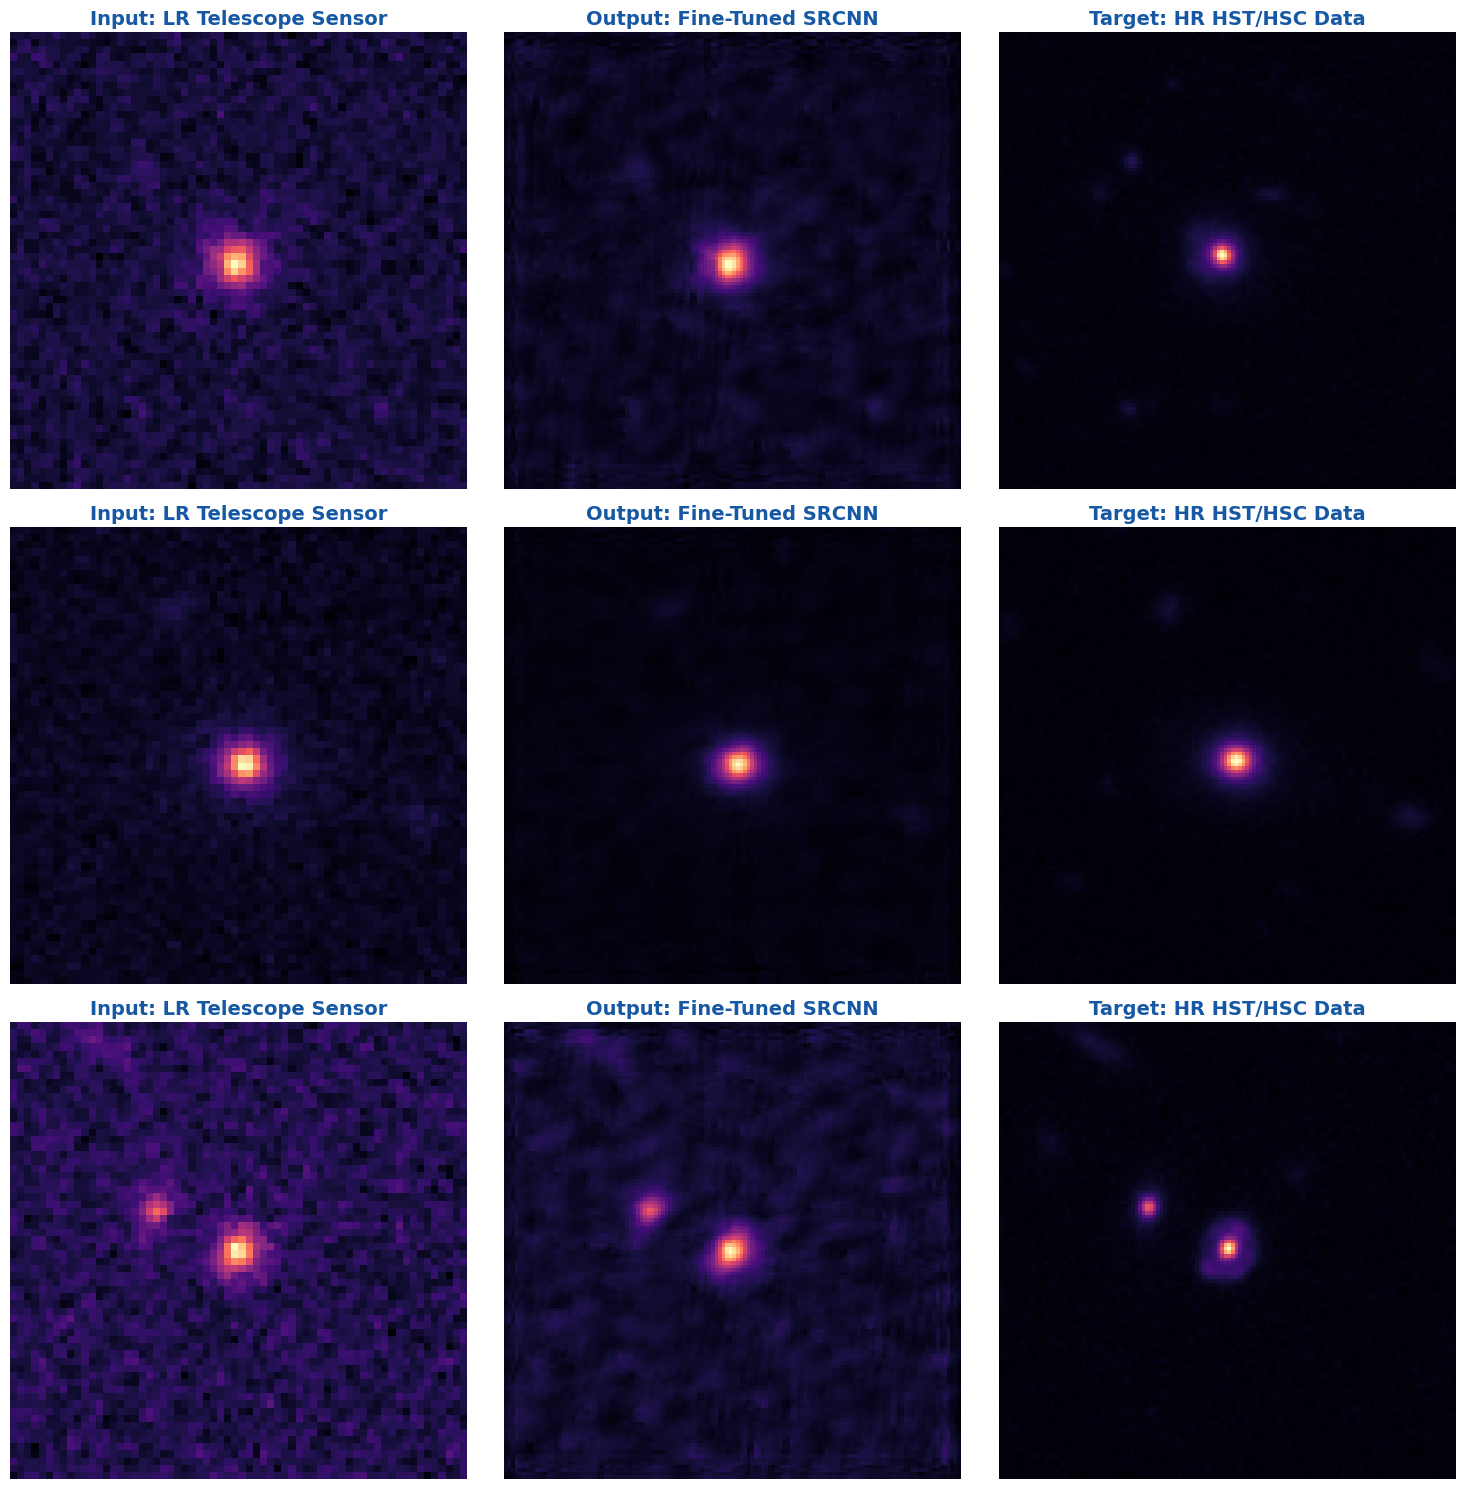

In [7]:
# executing visual validation on real HST/HSC sensor data
def visualize_domain_adaptation(model, dataloader, device, num_samples=3):
    model.eval()
    
    # intercepting a validation batch
    lr_imgs, hr_imgs = next(iter(dataloader))
    lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
    
    with torch.no_grad():
        sr_imgs = model(lr_imgs)
        
    # pushing tensors to cpu for rendering
    lr_imgs = lr_imgs.cpu().squeeze().numpy()
    hr_imgs = hr_imgs.cpu().squeeze().numpy()
    sr_imgs = sr_imgs.cpu().squeeze().numpy()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for i in range(num_samples):
        # 1. LR input
        axes[i, 0].imshow(lr_imgs[i], cmap='magma')
        axes[i, 0].set_title("Input: LR Telescope Sensor", fontsize=14, fontweight='bold', color='#1758A5')
        axes[i, 0].axis('off')
        
        # 2. Fine-Tuned Prediction
        axes[i, 1].imshow(sr_imgs[i], cmap='magma')
        axes[i, 1].set_title("Output: Fine-Tuned SRCNN", fontsize=14, fontweight='bold', color='#1758A5')
        axes[i, 1].axis('off')
        
        # 3. HR Ground Truth
        axes[i, 2].imshow(hr_imgs[i], cmap='magma')
        axes[i, 2].set_title("Target: HR HST/HSC Data", fontsize=14, fontweight='bold', color='#1758A5')
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.savefig('task_vib_transfer_results.png', dpi=300, bbox_inches='tight')
    plt.show()

print("rendering visual metrics...")
visualize_domain_adaptation(model, val_loader, device)